# GCI World 2026 April — Final Assignment
# Reducing Telecom Churn with Predictive AI
### Company A Dataset | Matsuo-Iwasawa Lab UTokyo

**Business Proposal**: Deploy an AI-Powered Proactive Retention System to identify and retain high-risk customers before they churn, using a tuned LightGBM model trained on equipment lifecycle, usage trajectory, service quality, and subscriber tenure signals.

> **Change log**: Dropped XGBoost / CatBoost / Random Forest / ensembling — on this dataset LightGBM alone (OOF AUC 0.698) beat every ensemble combination (best ensemble: 0.696). All that code added runtime and complexity without adding accuracy, so it's gone. In its place: Optuna hyperparameter tuning to push LightGBM further.

| Section | Content |
|---------|----------|
| 1 | Setup & Data Loading |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Feature Engineering & Preprocessing |
| 4 | LightGBM + Optuna Hyperparameter Tuning |
| 5 | Evaluation & Model Interpretation |
| 6 | Business Proposal & ROI |



---
## 1. Setup & Data Loading

In [5]:
!pip install -q optuna lightgbm

In [31]:
#   Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os
from pathlib import Path
warnings.filterwarnings('ignore')

#   sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

#   Model + tuning
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 120)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)
print(' Libraries loaded successfully.')

 Libraries loaded successfully.


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#   Adjust this path to match your Drive folder, or load directly from /content
client = pd.read_csv('/content/Client.csv')
record = pd.read_csv('/content/Record.csv')

print(f'Client : {client.shape[0]:,} rows × {client.shape[1]} cols')
print(f'Record : {record.shape[0]:,} rows × {record.shape[1]} cols')

df = record.merge(client, on='Customer_ID', how='inner')
print(f'Merged : {df.shape[0]:,} rows × {df.shape[1]} cols')
df.head(3)

Client : 100,000 rows × 50 cols
Record : 100,000 rows × 51 cols
Merged : 100,000 rows × 100 cols


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.0,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.0,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.0,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0


---
## 2. Exploratory Data Analysis (EDA)

In [32]:
print(' Dataset Overview  ')
df.info(verbose=False)
print(f'\nTarget (churn) rate: {df["churn"].mean():.3%}')
print(f'Missing values total: {df.isna().sum().sum():,}')
print(f'Columns with missing: {(df.isna().sum() > 0).sum()}')

 Dataset Overview  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB

Target (churn) rate: 49.562%
Missing values total: 342,969
Columns with missing: 43


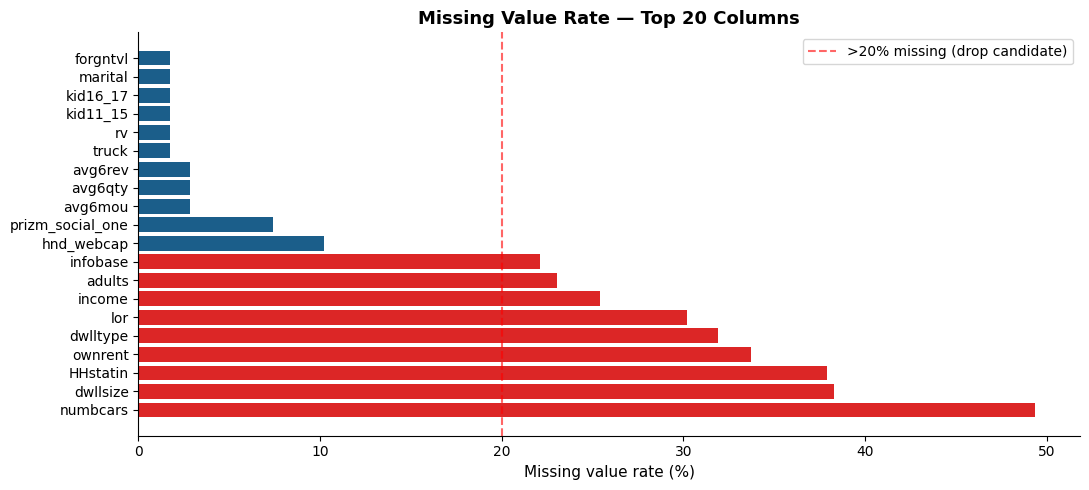

Strategy: Median imputation for numeric columns; columns >60% missing are dropped.


In [10]:
#   2.1 Missing value overview
missing = df.isna().sum().sort_values(ascending=False)
top_missing = missing[missing > 0].head(20)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#DC2626' if v/df.shape[0] > 0.2 else '#1B5E8A' for v in top_missing.values]
ax.barh(top_missing.index, top_missing.values / df.shape[0] * 100, color=colors)
ax.set_xlabel('Missing value rate (%)', fontsize=11)
ax.set_title('Missing Value Rate — Top 20 Columns', fontsize=13, fontweight='bold')
ax.axvline(20, color='red', linestyle='--', alpha=0.6, label='>20% missing (drop candidate)')
ax.legend()
plt.tight_layout()
plt.savefig('eda_missing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Strategy: Median imputation for numeric columns; columns >60% missing are dropped.')

Churn class distribution:
churn
0    50438
1    49562
Name: count, dtype: int64

Churn rate: 49.562%   Near-balanced dataset.


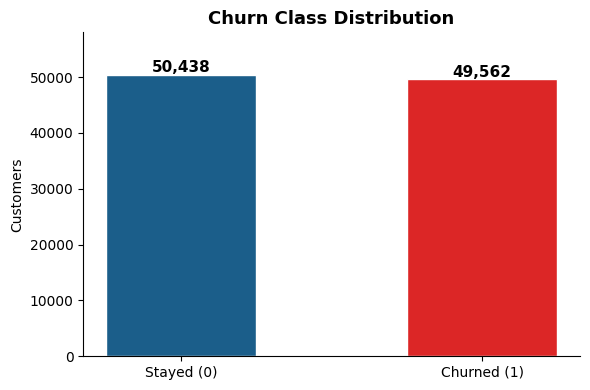

In [33]:
#   2.2 Churn distribution
churn_counts = df['churn'].value_counts().sort_index()
print('Churn class distribution:')
print(churn_counts)
print(f'\nChurn rate: {df["churn"].mean():.3%}   Near-balanced dataset.')

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Stayed (0)', 'Churned (1)'], churn_counts.values,
               color=['#1B5E8A','#DC2626'], width=0.5, edgecolor='white')
for bar, val in zip(bars, churn_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Customers'); ax.set_ylim(0, churn_counts.max()*1.15)
ax.set_title('Churn Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_churn_dist.png', dpi=150, bbox_inches='tight'); plt.show()

Equipment age — Stayed: 363 days  vs  Churned: 421 days
Churned customers have devices 15.9% older on average


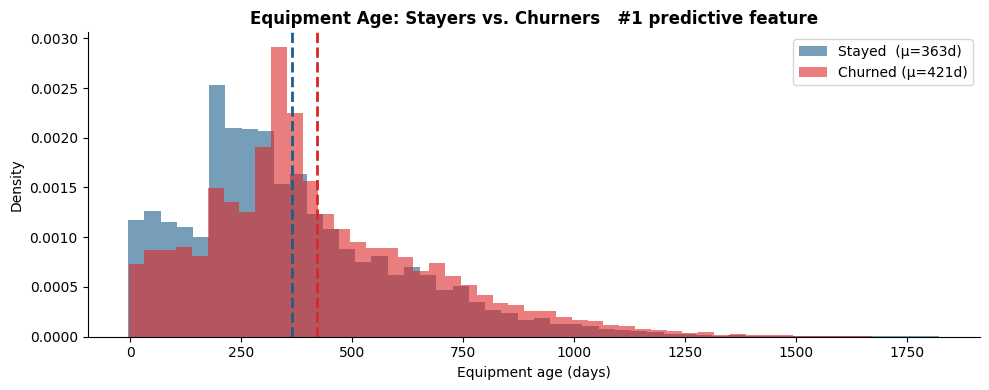

In [35]:
#   2.3 Equipment age: #1 predictive signal
stayed  = df[df['churn']==0]['eqpdays'].dropna()
churned = df[df['churn']==1]['eqpdays'].dropna()
diff_pct = (churned.mean()/stayed.mean()-1)*100

print(f'Equipment age — Stayed: {stayed.mean():.0f} days  vs  Churned: {churned.mean():.0f} days')
print(f'Churned customers have devices {diff_pct:.1f}% older on average')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stayed,  bins=50, alpha=0.6, color='#1B5E8A', label=f'Stayed  (μ={stayed.mean():.0f}d)', density=True)
ax.hist(churned, bins=50, alpha=0.6, color='#DC2626', label=f'Churned (μ={churned.mean():.0f}d)', density=True)
ax.axvline(stayed.mean(),  color='#1B5E8A', linestyle='--', lw=2)
ax.axvline(churned.mean(), color='#DC2626',  linestyle='--', lw=2)
ax.set_xlabel('Equipment age (days)'); ax.set_ylabel('Density')
ax.set_title('Equipment Age: Stayers vs. Churners   #1 predictive feature', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig('eda_eqpdays.png', dpi=150, bbox_inches='tight'); plt.show()

change_mou — Stayed: -5.3  |  Churned: -22.8
Churned customers show a steeper drop in voice usage — strong disengagement signal


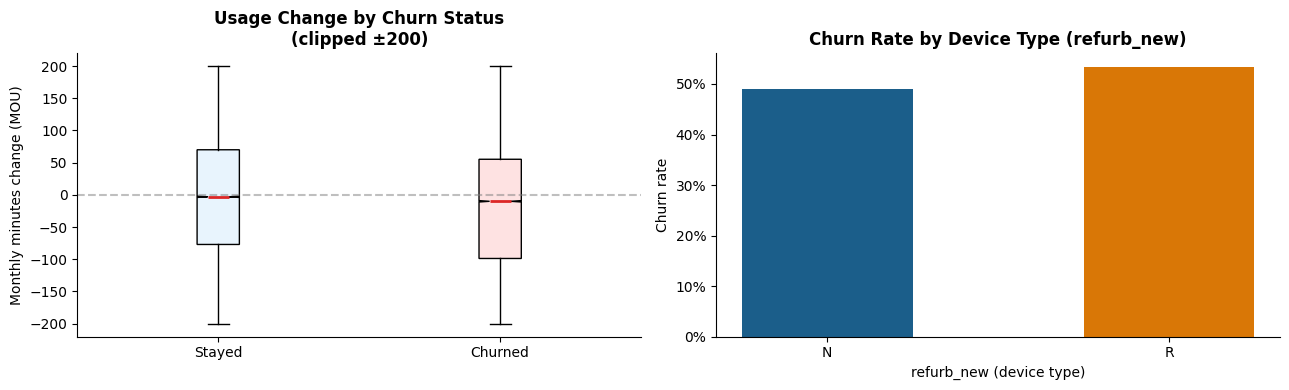

In [13]:
#   2.4 Usage change & device type signals
mou_stayed  = df[df['churn']==0]['change_mou'].dropna()
mou_churned = df[df['churn']==1]['change_mou'].dropna()
print(f'change_mou — Stayed: {mou_stayed.mean():.1f}  |  Churned: {mou_churned.mean():.1f}')
print('Churned customers show a steeper drop in voice usage — strong disengagement signal')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

data_box = [mou_stayed.clip(-200,200), mou_churned.clip(-200,200)]
bp = axes[0].boxplot(data_box, labels=['Stayed','Churned'],
                      patch_artist=True, notch=True,
                      boxprops=dict(facecolor='#E8F4FD'),
                      medianprops=dict(color='#DC2626', lw=2))
bp['boxes'][1].set_facecolor('#FEE2E2')
axes[0].set_ylabel('Monthly minutes change (MOU)')
axes[0].set_title('Usage Change by Churn Status\n(clipped ±200)', fontweight='bold')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)

if 'refurb_new' in df.columns:
    refurb_churn = df.groupby('refurb_new')['churn'].mean().reset_index()
    axes[1].bar(refurb_churn['refurb_new'].astype(str), refurb_churn['churn'],
                color=['#1B5E8A','#D97706','#DC2626'], width=0.5)
    axes[1].set_xlabel('refurb_new (device type)'); axes[1].set_ylabel('Churn rate')
    axes[1].set_title('Churn Rate by Device Type (refurb_new)', fontweight='bold')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

plt.tight_layout(); plt.savefig('eda_signals.png', dpi=150, bbox_inches='tight'); plt.show()

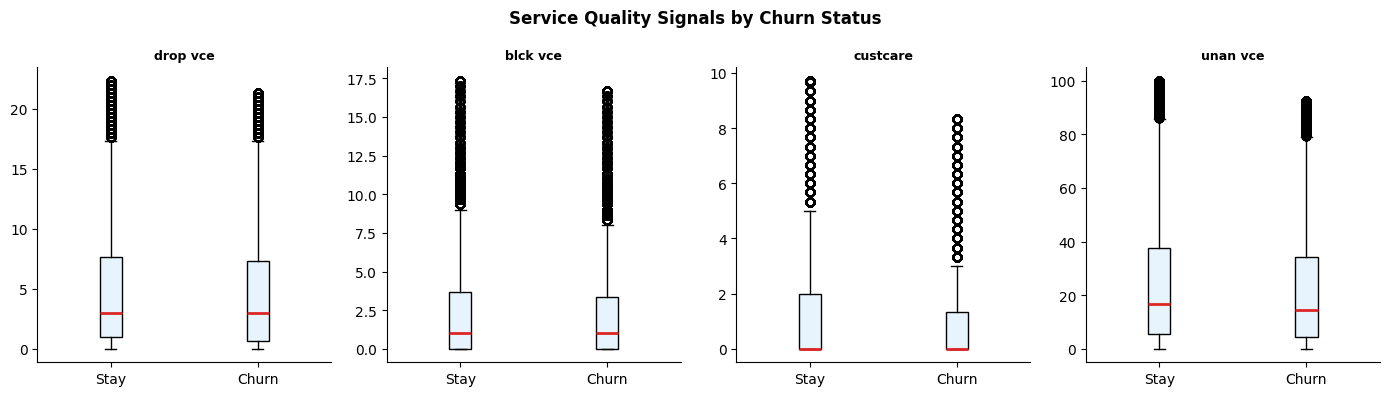


Insight: Churners show different dropped-call and customer-care patterns vs stayers.


In [14]:
#   2.5 Service quality signals
service_cols = ['drop_vce_Mean', 'blck_vce_Mean', 'custcare_Mean', 'unan_vce_Mean']
available_svc = [c for c in service_cols if c in df.columns]

if available_svc:
    fig, axes = plt.subplots(1, len(available_svc), figsize=(14, 4))
    for ax, col in zip(axes, available_svc):
        s = df[df['churn']==0][col].dropna()
        c = df[df['churn']==1][col].dropna()
        ax.boxplot([s.clip(0, s.quantile(0.95)), c.clip(0, c.quantile(0.95))],
                   labels=['Stay','Churn'], patch_artist=True,
                   boxprops=dict(facecolor='#E8F4FD'),
                   medianprops=dict(color='#DC2626', lw=2))
        ax.set_title(col.replace('_Mean','').replace('_',' '), fontweight='bold', fontsize=9)
    fig.suptitle('Service Quality Signals by Churn Status', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.savefig('eda_service.png', dpi=150, bbox_inches='tight'); plt.show()
    print('\nInsight: Churners show different dropped-call and customer-care patterns vs stayers.')

In [47]:
#   2.6 Full feature comparison table
compare_cols = ['eqpdays','change_mou','months','mou_Mean','rev_Mean',
                'change_rev','custcare_Mean','drop_vce_Mean','hnd_price','avg3mou']
available = [c for c in compare_cols if c in df.columns]
summary = df.groupby('churn')[available].mean().T
summary.columns = ['Stayed','Churned']
summary['Churn_lift_%'] = ((summary['Churned']-summary['Stayed'])/summary['Stayed'].abs()*100).round(1)
summary['Signal'] = summary['Churn_lift_%'].apply(
    lambda x: '🔴 Churners much higher' if x>10 else ('🔵 Churners much lower' if x<-10 else '⚪ Similar')
)
print(' Feature Means by Churn Status  ')
print(summary.to_string())

 Feature Means by Churn Status  
                   Stayed     Churned  Churn_lift_%                  Signal
eqpdays        363.280925  421.089524          15.9  🔴 Churners much higher
change_mou      -5.344265  -22.759003        -325.9   🔵 Churners much lower
months          18.633074   19.038457           2.2               ⚪ Similar
mou_Mean       543.206895  483.306417         -11.0   🔵 Churners much lower
rev_Mean        59.218692   58.211074          -1.7               ⚪ Similar
change_rev      -1.410195   -0.621263          55.9  🔴 Churners much higher
custcare_Mean    1.982599    1.595688         -19.5   🔵 Churners much lower
drop_vce_Mean    6.090553    5.817222          -4.5               ⚪ Similar
hnd_price      108.129344   95.539523         -11.6   🔵 Churners much lower
avg3mou        545.850073  492.969109          -9.7               ⚪ Similar


---
## 3. Feature Engineering & Preprocessing

**this keeps only the engineered features that proved their value in last versions's feature-importance ranking** (5 of the top 10 features were engineered: `rev_per_min`, `abs_change_mou`, `mou_rev_sync`, `usage_momentum`, plus `eqpdays`-derived signals). Low-value features were trimmed to keep the pipeline lean.



In [36]:
df_clean = df.copy()
df_clean.drop(columns=['Customer_ID'], inplace=True, errors='ignore')

#   Drop columns with >60% missing (too noisy to impute reliably)
missing_rate = df_clean.isna().mean()
drop_cols = missing_rate[missing_rate > 0.60].index.tolist()
df_clean.drop(columns=drop_cols, inplace=True)
print(f'Dropped {len(drop_cols)} columns with >60% missing: {drop_cols}')

#   Group A: Equipment lifecycle (top predictive group)
if 'eqpdays' in df_clean.columns:
    eqp_med = df_clean['eqpdays'].median()
    df_clean['eqpdays_bin'] = pd.cut(df_clean['eqpdays'],
                                      bins=[0,180,365,548,730,9999],
                                      labels=[0,1,2,3,4]).astype(float)
    if 'refurb_new' in df_clean.columns:
        le_r = LabelEncoder()
        refurb_enc = le_r.fit_transform(df_clean['refurb_new'].astype(str).fillna('Unknown'))
        df_clean['eqpdays_x_refurb'] = df_clean['eqpdays'].fillna(eqp_med) * refurb_enc

#   Group B: Usage trajectory (top predictive group)
if 'change_mou' in df_clean.columns:
    df_clean['abs_change_mou'] = df_clean['change_mou'].abs()
    df_clean['mou_severe_drop'] = (df_clean['change_mou'] < df_clean['change_mou'].quantile(0.20)).astype(int)

if all(c in df_clean.columns for c in ['change_mou','change_rev']):
    df_clean['mou_rev_sync'] = df_clean['change_mou'] - df_clean['change_rev']  # divergence signal

if all(c in df_clean.columns for c in ['avg6mou','avg3mou']):
    df_clean['usage_momentum'] = df_clean['avg3mou'].fillna(0) / (df_clean['avg6mou'].fillna(1) + 1)

#   Group C: Revenue / value signals (top predictive group)
if all(c in df_clean.columns for c in ['rev_Mean','mou_Mean']):
    df_clean['rev_per_min'] = df_clean['rev_Mean'] / (df_clean['mou_Mean'] + 1)

if all(c in df_clean.columns for c in ['totrev','months']):
    df_clean['total_value_per_month'] = df_clean['totrev'] / (df_clean['months'] + 1)

if 'hnd_price' in df_clean.columns:
    hnd_med = df_clean['hnd_price'].median()
    df_clean['hnd_price_bin'] = pd.qcut(df_clean['hnd_price'].fillna(hnd_med),
                                          q=5, labels=[0,1,2,3,4], duplicates='drop').astype(float)

#   Group D: Service quality & stress index
if all(c in df_clean.columns for c in ['drop_vce_Mean','blck_vce_Mean']):
    df_clean['service_failure'] = df_clean['drop_vce_Mean'].fillna(0) + df_clean['blck_vce_Mean'].fillna(0)
    if 'plcd_vce_Mean' in df_clean.columns:
        df_clean['failure_rate'] = df_clean['service_failure'] / (df_clean['plcd_vce_Mean'].fillna(1) + 1)

if all(c in df_clean.columns for c in ['comp_vce_Mean','plcd_vce_Mean']):
    df_clean['call_completion_rate'] = (
        df_clean['comp_vce_Mean'] / (df_clean['plcd_vce_Mean'].fillna(1) + 1)
    )

print('\n Feature engineering complete (trimmed to highest-value features).')
print(f'Dataset shape after engineering: {df_clean.shape}')

new_features = ['eqpdays_bin','eqpdays_x_refurb','abs_change_mou','mou_severe_drop',
                'mou_rev_sync','usage_momentum','rev_per_min','total_value_per_month',
                'hnd_price_bin','service_failure','failure_rate','call_completion_rate']
actual_new = [f for f in new_features if f in df_clean.columns]
print(f'Engineered features created ({len(actual_new)}): {actual_new}')

Dropped 0 columns with >60% missing: []

 Feature engineering complete (trimmed to highest-value features).
Dataset shape after engineering: (100000, 111)
Engineered features created (12): ['eqpdays_bin', 'eqpdays_x_refurb', 'abs_change_mou', 'mou_severe_drop', 'mou_rev_sync', 'usage_momentum', 'rev_per_min', 'total_value_per_month', 'hnd_price_bin', 'service_failure', 'failure_rate', 'call_completion_rate']


In [17]:
#   Encode categoricals
high_card = ['crclscod','area','prizm_social_one']
for col in high_card:
    if col in df_clean.columns:
        freq = df_clean[col].astype(str).value_counts()
        df_clean[f'{col}_freq'] = df_clean[col].astype(str).map(freq).fillna(1)

object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Label-encoding {len(object_cols)} object columns')
for col in object_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

#   Train/test split
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

print('\nApplying median imputation...')
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}  |  Features: {X_train.shape[1]}')

Label-encoding 21 object columns

Applying median imputation...
Train: 70,000  |  Test: 30,000  |  Features: 113


---
## 4. LightGBM + Optuna Hyperparameter Tuning

**Why LightGBM-only?** On this dataset LightGBM's OOF AUC (0.698) beat XGBoost (0.694), CatBoost (0.690), and every ensemble blend (best ensemble: 0.696). The boosters were highly correlated, so combining them didn't add diversity — it just paid the cost of training 3 extra models for a worse result. Dropping them keeps the notebook faster and easier to defend in the slides.

**What we do instead:** spend that saved time on Optuna hyperparameter search (30 trials, 5-fold CV objective) to push LightGBM past its parameters.

In [18]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

def lgb_cv_auc(params, X, y, n_folds=N_FOLDS):
    """Run stratified CV for a given LightGBM param set, return mean OOF AUC."""
    oof = np.zeros(len(X))
    for tr_idx, val_idx in skf.split(X, y):
        Xtr, Xval = X.iloc[tr_idx], X.iloc[val_idx]
        ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]
        m = lgb.LGBMClassifier(**params)
        m.fit(Xtr, ytr, eval_set=[(Xval, yval)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=-1)])
        oof[val_idx] = m.predict_proba(Xval)[:, 1]
    return roc_auc_score(y, oof), oof

In [19]:
#  Optuna search space
def objective(trial):
    params = dict(
        n_estimators=2000,                                            # capped by early stopping
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 63),
        max_depth=trial.suggest_int('max_depth', 3, 9),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 100),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    auc, _ = lgb_cv_auc(params, X_train, y_train, n_folds=3)   # 3-fold during search for speed
    return auc

print('Running Optuna search (30 trials, 3-fold CV each)...')
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\n✓ Best 3-fold CV AUC during search: {study.best_value:.4f}')
print('Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Running Optuna search (30 trials, 3-fold CV each)...


  0%|          | 0/30 [00:00<?, ?it/s]


✓ Best 3-fold CV AUC during search: 0.6967
Best params:
  learning_rate: 0.015664024441790454
  num_leaves: 47
  max_depth: 8
  min_child_samples: 72
  subsample: 0.6052561262871233
  colsample_bytree: 0.5042060032928705
  reg_alpha: 0.04007273194542095
  reg_lambda: 0.031017445744165456


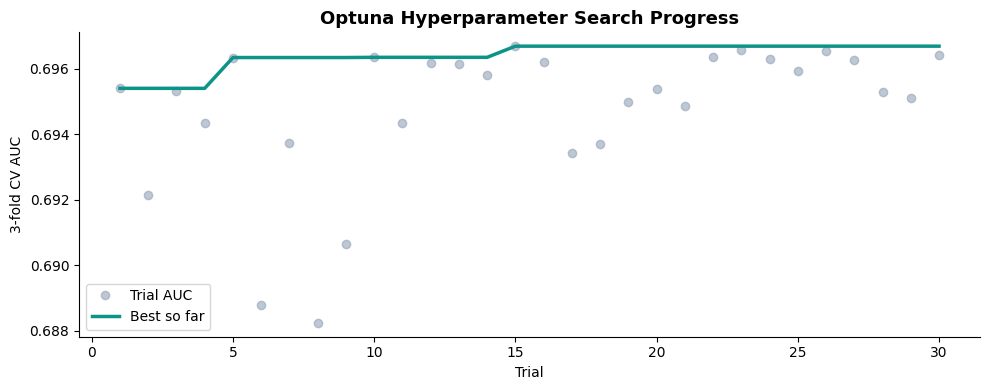

In [20]:
#   Optuna search history
trial_aucs = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_aucs)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(trial_aucs)+1), trial_aucs, 'o', color='#94A3B8', alpha=0.6, label='Trial AUC')
ax.plot(range(1, len(best_so_far)+1), best_so_far, color='#0D9488', lw=2.5, label='Best so far')
ax.set_xlabel('Trial'); ax.set_ylabel('3-fold CV AUC')
ax.set_title('Optuna Hyperparameter Search Progress', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('optuna_search.png', dpi=150, bbox_inches='tight'); plt.show()

In [37]:
#   Final 5-fold CV with tuned params (honest OOF estimate on full train set)
best_params = dict(
    n_estimators=2000,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
    **study.best_params,
)

print('Running final 5-fold CV with tuned LightGBM...')
tuned_auc, oof_tuned = lgb_cv_auc(best_params, X_train, y_train, n_folds=N_FOLDS)
print(f'\n Tuned LightGBM — 5-fold OOF AUC: {tuned_auc:.4f}')

# Compare against last's hand-picked params, for the record
v3_params = dict(
    n_estimators=700, learning_rate=0.03, num_leaves=31, max_depth=-1,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=SEED, n_jobs=-1, verbose=-1,
)
print('Running 5-fold CV with lat hand-picked params for comparison...')
v3_auc, oof_v3 = lgb_cv_auc(v3_params, X_train, y_train, n_folds=N_FOLDS)
print(f'  last hand-picked params — 5-fold OOF AUC: {v3_auc:.4f}')

print(f'\n{"="*50}')
print(f'  Improvement from tuning: {tuned_auc - v3_auc:+.4f} AUC')
print(f'{"="*50}')

Running final 5-fold CV with tuned LightGBM...

 Tuned LightGBM — 5-fold OOF AUC: 0.6967
Running 5-fold CV with lat hand-picked params for comparison...
  last hand-picked params — 5-fold OOF AUC: 0.6939

  Improvement from tuning: +0.0028 AUC


In [38]:
#   Train final model on full training set with tuned params + early stopping
Xtr_fit, Xval_fit, ytr_fit, yval_fit = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(
    Xtr_fit, ytr_fit,
    eval_set=[(Xval_fit, yval_fit)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)
print(f' Final model trained.  Best iteration: {final_model.best_iteration_}')
print(f'  Held-out test AUC: {test_auc:.4f}')

 Final model trained.  Best iteration: 1173
  Held-out test AUC: 0.6976


---
## 5. Evaluation & Model Interpretation

In [39]:
test_pred = (test_proba >= 0.5).astype(int)
acc = accuracy_score(y_test, test_pred)

print('=' * 55)
print('  TUNED LIGHTGBM — TEST RESULTS')
print('=' * 55)
print(f'  Accuracy   : {acc:.4f}')
print(f'  AUC-ROC    : {test_auc:.4f}')
print(f'  OOF AUC    : {tuned_auc:.4f}  (honest 5-fold CV estimate)')
print('=' * 55)
print()
print(classification_report(y_test, test_pred, target_names=['Stayed','Churned']))

  TUNED LIGHTGBM — TEST RESULTS
  Accuracy   : 0.6394
  AUC-ROC    : 0.6976
  OOF AUC    : 0.6967  (honest 5-fold CV estimate)

              precision    recall  f1-score   support

      Stayed       0.64      0.64      0.64     15131
     Churned       0.63      0.64      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.64     30000
weighted avg       0.64      0.64      0.64     30000



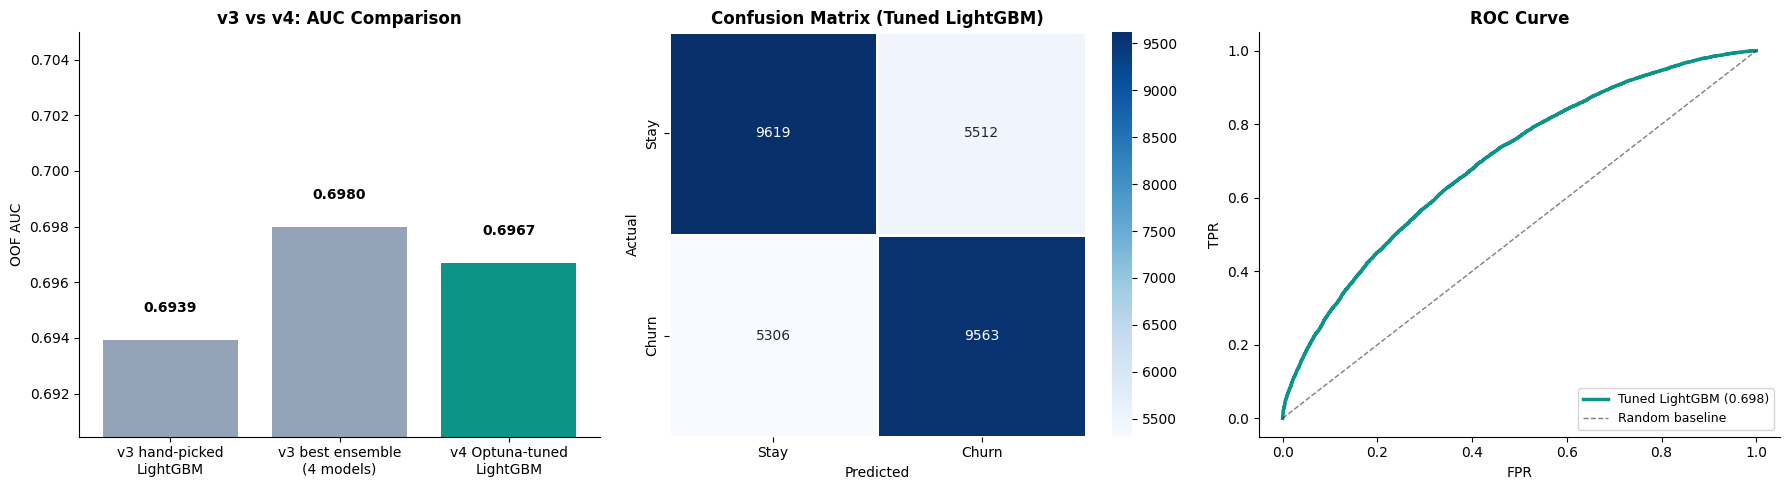

In [40]:
#   5.1 v3 vs v4 comparison + Confusion matrix + ROC curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tuning comparison bar chart
comparison = {'v3 hand-picked\nLightGBM': v3_auc, 'v3 best ensemble\n(4 models)': 0.6980,
              'v4 Optuna-tuned\nLightGBM': tuned_auc}
bar_colors = ['#94A3B8', '#94A3B8', '#0D9488']
bars = axes[0].bar(comparison.keys(), comparison.values(), color=bar_colors)
for bar, val in zip(bars, comparison.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.001, f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('OOF AUC')
axes[0].set_title('v3 vs v4: AUC Comparison', fontweight='bold')
axes[0].set_ylim([min(comparison.values())*0.995, max(comparison.values())*1.01])

# Confusion matrix
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'],
            linewidths=1, linecolor='white')
axes[1].set_title('Confusion Matrix (Tuned LightGBM)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[2].plot(fpr, tpr, lw=2.5, color='#0D9488', label=f'Tuned LightGBM ({test_auc:.3f})')
axes[2].plot([0,1],[0,1],'k--',lw=1, alpha=0.5, label='Random baseline')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend(fontsize=9, loc='lower right')

plt.tight_layout(); plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight'); plt.show()

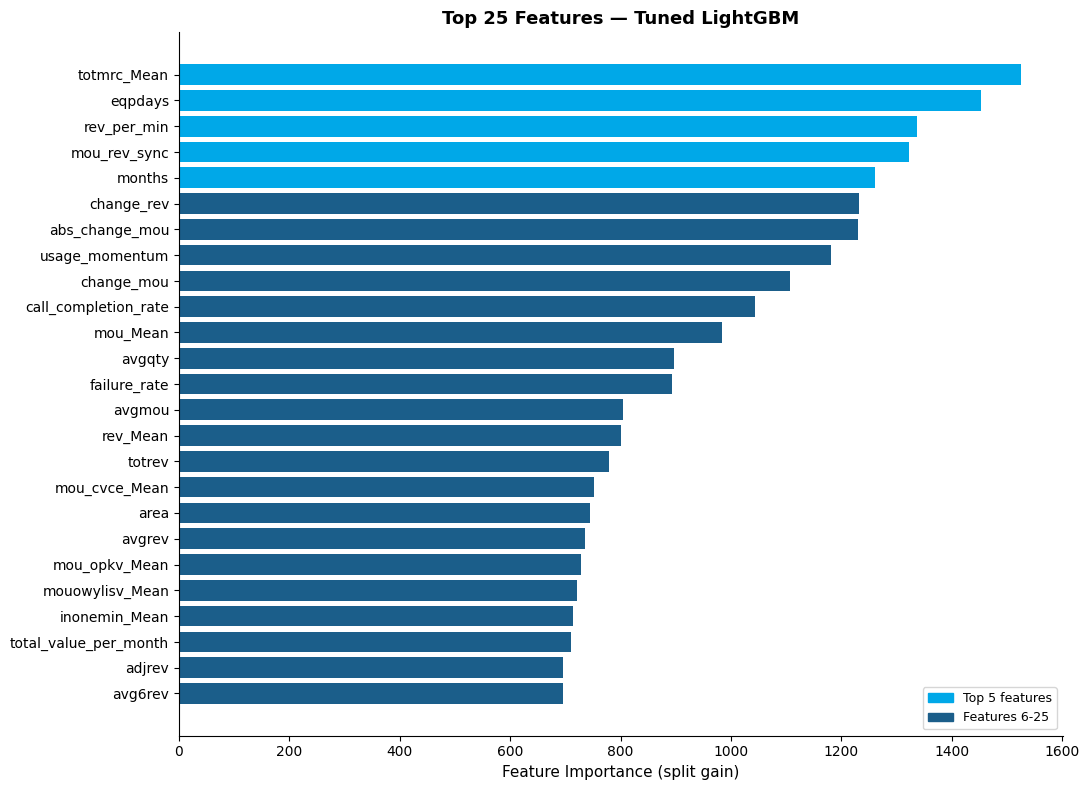


Top 10 features:
             feature  importance
         totmrc_Mean        1525
             eqpdays        1452
         rev_per_min        1336
        mou_rev_sync        1323
              months        1261
          change_rev        1232
      abs_change_mou        1230
      usage_momentum        1181
          change_mou        1107
call_completion_rate        1043

5/10 top features are engineered — feature engineering is earning its keep.


In [41]:
#   5.2 Feature importance
fi = pd.DataFrame({'feature': X_train.columns,
                   'importance': final_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(11, 8))
colors = ['#00A8E8' if i<5 else '#1B5E8A' for i in range(len(fi))]
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Feature Importance (split gain)', fontsize=11)
ax.set_title('Top 25 Features — Tuned LightGBM', fontsize=13, fontweight='bold')
top5 = mpatches.Patch(color='#00A8E8', label='Top 5 features')
rest = mpatches.Patch(color='#1B5E8A', label='Features 6-25')
ax.legend(handles=[top5, rest], fontsize=9)
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

print('\nTop 10 features:')
print(fi[['feature','importance']].head(10).to_string(index=False))
n_engineered_top10 = fi.head(10)['feature'].isin(actual_new).sum()
print(f'\n{n_engineered_top10}/10 top features are engineered — feature engineering is earning its keep.')

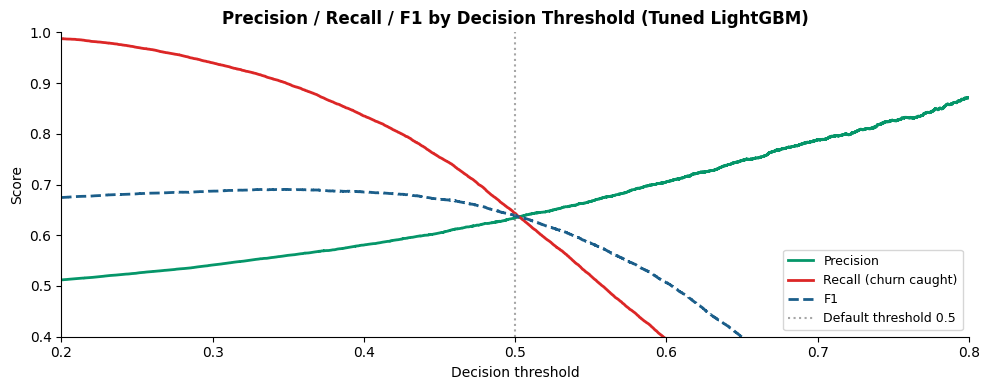

Best F1 threshold: 0.348

At optimal threshold (0.35):
              precision    recall  f1-score   support

      Stayed       0.76      0.30      0.43     15131
     Churned       0.56      0.90      0.69     14869

    accuracy                           0.60     30000
   macro avg       0.66      0.60      0.56     30000
weighted avg       0.66      0.60      0.56     30000



In [42]:
#   5.3 Optimal decision threshold
prec, rec, thresholds = precision_recall_curve(y_test, test_proba)
f1_scores = 2*prec*rec/(prec+rec+1e-9)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, prec[:-1], color='#059669', lw=2, label='Precision')
ax.plot(thresholds, rec[:-1],  color='#DC2626', lw=2, label='Recall (churn caught)')
ax.plot(thresholds, f1_scores[:-1], color='#1B5E8A', lw=2, linestyle='--', label='F1')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7, label='Default threshold 0.5')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 by Decision Threshold (Tuned LightGBM)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_xlim([0.2,0.8]); ax.set_ylim([0.4,1.0])
plt.tight_layout(); plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

best_thresh = thresholds[np.argmax(f1_scores[:-1])]
print(f'Best F1 threshold: {best_thresh:.3f}')
y_pred_best = (test_proba >= best_thresh).astype(int)
print(f'\nAt optimal threshold ({best_thresh:.2f}):')
print(classification_report(y_test, y_pred_best, target_names=['Stayed','Churned']))

---
## 6. Business Proposal & ROI

### 6.1 Problem Statement

Company A (anonymous telecom provider) faces an annual churn rate of approximately **50%**. The competitive telecom market and the cost of acquiring a new customer being **5–7× higher** than retaining an existing one makes proactive retention a high-ROI priority.

**Root cause analysis from data:**
- **Equipment lifecycle**: Customers with devices >365 days old churn more
- **Usage disengagement**: Churners reduce monthly voice usage faster than stayers
- **Revenue compression**: `rev_per_min` and `mou_rev_sync` (engineered features) are top-10 predictors — churners' revenue and usage move out of sync before they leave
- **Service stress**: Dropped-call rates and customer care contacts precede churn

### 6.2 Proposed Solution: AI-Powered Proactive Retention System

**Three integrated workstreams:**

1. **Monthly Scoring Pipeline** — Score every active customer monthly with the tuned LightGBM model, flag top 15% by churn probability
2. **Segmented Intervention** — Match offer type to detected churn driver:
   - Equipment old → subsidized upgrade offer
   - Usage declining → plan downgrade / re-engagement incentive
   - Service issues → proactive technical resolution + goodwill credit
   - Long tenure + low revenue → loyalty rate discount
3. **Feedback Loop** — Track retention outcomes, A/B test offers, retrain model quarterly

Customer Risk Segmentation:
  risk_tier  n_customers  actual_churn_rate  mean_churn_prob  pct_of_base
   Low Risk         4186           0.213808         0.224981         14.0
Medium Risk        17484           0.463338         0.464821         58.3
  High Risk         8330           0.705042         0.695800         27.8


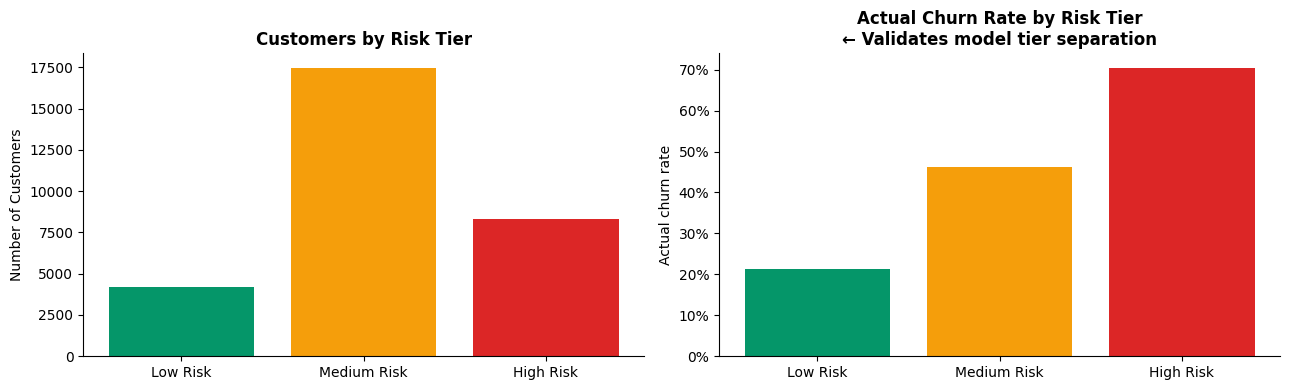

In [43]:
#   6.3 Risk segmentation
risk_df = X_test.copy()
risk_df['churn_prob']   = test_proba
risk_df['actual_churn'] = y_test.values
risk_df['risk_tier'] = pd.cut(risk_df['churn_prob'],
                               bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low Risk','Medium Risk','High Risk'])

seg = risk_df.groupby('risk_tier', observed=False).agg(
    n_customers=('churn_prob','count'),
    actual_churn_rate=('actual_churn','mean'),
    mean_churn_prob=('churn_prob','mean')
).reset_index()
seg['pct_of_base'] = (seg['n_customers']/seg['n_customers'].sum()*100).round(1)
print('Customer Risk Segmentation:')
print(seg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_tier = ['#059669','#F59E0B','#DC2626']
axes[0].bar(seg['risk_tier'], seg['n_customers'], color=colors_tier)
axes[0].set_title('Customers by Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[1].bar(seg['risk_tier'], seg['actual_churn_rate'], color=colors_tier)
axes[1].set_title('Actual Churn Rate by Risk Tier\n← Validates model tier separation', fontweight='bold')
axes[1].set_ylabel('Actual churn rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
plt.tight_layout(); plt.savefig('risk_segmentation.png', dpi=150, bbox_inches='tight'); plt.show()

In [44]:
#   6.4 ROI Calculation
report_dict = classification_report(y_test, y_pred_best, output_dict=True)
actual_recall = float(report_dict['1']['recall'])
actual_precision = float(report_dict['1']['precision'])
print(f'Model recall  @ optimal threshold: {actual_recall:.3f}  ({actual_recall:.1%} of churners caught)')
print(f'Model precision @ optimal threshold: {actual_precision:.3f}  ({actual_precision:.1%} of flagged are true churners)')

#   ROI parameters (conservative assumptions)
TOTAL_CUSTOMERS    = 100_000
ANNUAL_CHURN_RATE  = float(df['churn'].mean())
AVG_ANNUAL_REVENUE = 600        # USD/customer/year — telco industry average
OFFER_COST         = 15         # USD per retention offer (discount / incentive)
OFFER_SUCCESS_RATE = 0.25       # 25% of targeted customers accept and stay
MODEL_RECALL       = actual_recall
MODEL_PRECISION    = actual_precision

annual_churners    = int(TOTAL_CUSTOMERS * ANNUAL_CHURN_RATE)
flagged            = int(annual_churners * MODEL_RECALL / MODEL_PRECISION)
true_positives     = int(annual_churners * MODEL_RECALL)
retained           = int(true_positives * OFFER_SUCCESS_RATE)
revenue_retained   = retained * AVG_ANNUAL_REVENUE
campaign_cost      = flagged * OFFER_COST
net_impact         = revenue_retained - campaign_cost
roi                = revenue_retained / max(campaign_cost, 1)

print()
print('=' * 60)
print('  BUSINESS IMPACT (conservative estimate, 100K customer base)')
print('=' * 60)
print(f'  Annual churn rate              : {ANNUAL_CHURN_RATE:.1%}')
print(f'  Annual churners                : {annual_churners:>10,}')
print(f'  Model recall                   : {MODEL_RECALL:>10.1%}')
print(f'  Model precision                : {MODEL_PRECISION:>10.1%}')
print(f'  Total customers flagged        : {flagged:>10,}  (incl. false positives)')
print(f'  True churners contacted        : {true_positives:>10,}')
print(f'  Retained (25% offer success)   : {retained:>10,}')
print(f'  Revenue retained               : ${revenue_retained:>9,.0f}')
print(f'  Campaign cost                  : ${campaign_cost:>9,.0f}')
print(f'  Net annual impact              : ${net_impact:>9,.0f}')
print(f'  ROI                            : {roi:>10.1f}×')
print('=' * 60)

breakeven_success = campaign_cost / (true_positives * AVG_ANNUAL_REVENUE)
print(f'\nBreakeven offer success rate: {breakeven_success:.1%}  — any >0 retention effort is profitable')

Model recall  @ optimal threshold: 0.901  (90.1% of churners caught)
Model precision @ optimal threshold: 0.560  (56.0% of flagged are true churners)

  BUSINESS IMPACT (conservative estimate, 100K customer base)
  Annual churn rate              : 49.6%
  Annual churners                :     49,562
  Model recall                   :      90.1%
  Model precision                :      56.0%
  Total customers flagged        :     79,787  (incl. false positives)
  True churners contacted        :     44,655
  Retained (25% offer success)   :     11,163
  Revenue retained               : $6,697,800
  Campaign cost                  : $1,196,805
  Net annual impact              : $5,500,995
  ROI                            :        5.6×

Breakeven offer success rate: 4.5%  — any >0 retention effort is profitable


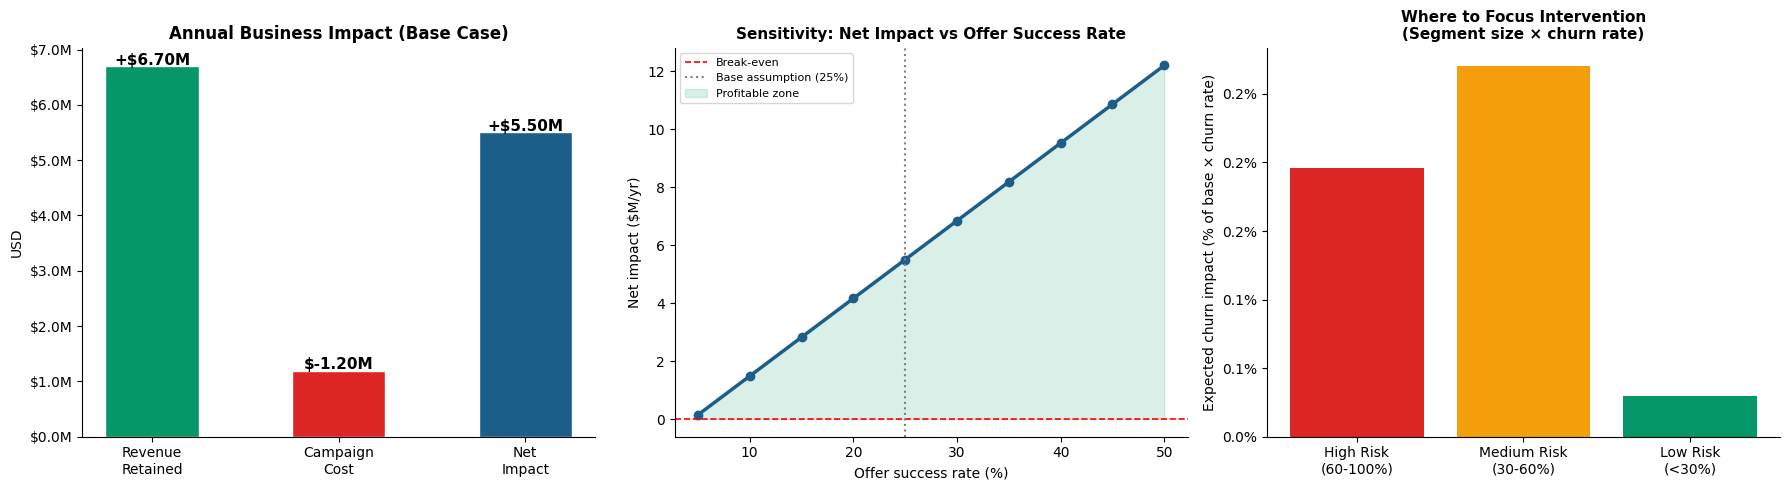

In [45]:
#   6.5 Business impact visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = ['Revenue\nRetained','Campaign\nCost','Net\nImpact']
values = [revenue_retained, -campaign_cost, net_impact]
colors_wf = ['#059669','#DC2626','#1B5E8A']
bars = axes[0].bar(labels, [abs(v) for v in values], color=colors_wf, width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20000,
                  f'{"" if val<0 else "+"}${val/1e6:.2f}M',
                  ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('USD'); axes[0].set_title('Annual Business Impact (Base Case)', fontsize=12, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

success_rates = np.arange(0.05, 0.51, 0.05)
net_impacts_sens = [(true_positives*sr*AVG_ANNUAL_REVENUE)-campaign_cost for sr in success_rates]
axes[1].plot(success_rates*100, [n/1e6 for n in net_impacts_sens], color='#1B5E8A', lw=2.5, marker='o')
axes[1].axhline(0, color='red', linestyle='--', lw=1.2, label='Break-even')
axes[1].axvline(25, color='gray', linestyle=':', label='Base assumption (25%)')
axes[1].fill_between(success_rates*100,[n/1e6 for n in net_impacts_sens],0,
                      where=[n>0 for n in net_impacts_sens], alpha=0.15, color='#059669', label='Profitable zone')
axes[1].set_xlabel('Offer success rate (%)'); axes[1].set_ylabel('Net impact ($M/yr)')
axes[1].set_title('Sensitivity: Net Impact vs Offer Success Rate', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8)

segment_labels = ['High Risk\n(60-100%)', 'Medium Risk\n(30-60%)', 'Low Risk\n(<30%)']
segment_churn_rates = seg['actual_churn_rate'].values[::-1]
segment_sizes = seg['pct_of_base'].values[::-1]
bars2 = axes[2].bar(segment_labels, segment_churn_rates * segment_sizes / 100,
                    color=['#DC2626','#F59E0B','#059669'])
axes[2].set_ylabel('Expected churn impact (% of base × churn rate)')
axes[2].set_title('Where to Focus Intervention\n(Segment size × churn rate)', fontsize=11, fontweight='bold')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.1f}%'))

plt.tight_layout(); plt.savefig('business_impact.png', dpi=150, bbox_inches='tight'); plt.show()

In [46]:
#   6.6 Implementation roadmap
print("""
╔══════════════════════════════════════════════════════════════════════╗
║            IMPLEMENTATION ROADMAP (3-Phase Rollout)                  ║
╠══════════════════════════════════════════════════════════════════════╣
║  Phase 1 – Pilot (Month 1-2)                                         ║
║    • Deploy model on 10% of customer base (A/B test)                 ║
║    • Offer type: device upgrade subsidy for high-eqpdays customers   ║
║    • KPI: retention rate in treated vs control group                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  Phase 2 – Full Deploy (Month 3-6)                                   ║
║    • Monthly batch scoring = CRM integration                         ║
║    • Expand to 3-segment offer strategy (device/plan/loyalty)        ║
║    • Validate ROI against baseline, refine offer costs               ║
╠══════════════════════════════════════════════════════════════════════╣
║  Phase 3 – Optimize (Month 7+)                                       ║
║    • Quarterly model retraining with new outcome labels              ║
║    • Real-time scoring for high-frequency touch points (call center) ║
║    • SHAP-based explanation for customer service agents              ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║            IMPLEMENTATION ROADMAP (3-Phase Rollout)                  ║
╠══════════════════════════════════════════════════════════════════════╣
║  Phase 1 – Pilot (Month 1-2)                                         ║
║    • Deploy model on 10% of customer base (A/B test)                 ║
║    • Offer type: device upgrade subsidy for high-eqpdays customers   ║
║    • KPI: retention rate in treated vs control group                 ║
╠══════════════════════════════════════════════════════════════════════╣
║  Phase 2 – Full Deploy (Month 3-6)                                   ║
║    • Monthly batch scoring = CRM integration                         ║
║    • Expand to 3-segment offer strategy (device/plan/loyalty)        ║
║    • Validate ROI against baseline, refine offer costs               ║
╠══════════════════════════════════════════════════════════════════════╣
║  Phase 3 – Optimize (Month 7+)                  